![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)


## Einführung in Zeitreihen
Eine **Zeitreihe** ist eine Folge von Datenpunkten, die in zeitlicher Reihenfolge erfasst wurden. Typische Beispiele sind Messwerte wie Temperaturen, Umsatzzahlen, Aktienkurse oder Besucherstatistiken, die über einen definierten Zeitraum verteilt aufgezeichnet werden. Das Ziel der Zeitreihenanalyse ist es, Muster zu erkennen, Prognosen abzuleiten und Zusammenhänge über die Zeit zu untersuchen.

### Typische Fragestellungen in der Zeitreihenanalyse
1. **Trends**: Gibt es einen langfristigen Trend (z.B. steigende Temperatur, wachsende Nachfrage etc.)?  
2. **Saisonalität**: Gibt es wiederkehrende Muster zu bestimmten Zeitpunkten (z.B. Wochen-, Tages- oder Jahreszyklen)?  
3. **Periodizität**: Treten zyklische Verhaltensweisen in regelmäßigen Abständen auf?  
4. **Ausreißer**: Gibt es besondere Ereignisse oder Werte, die stark vom normalen Verlauf abweichen?  
5. **Vorhersagen**: Wie kann man zukünftige Werte anhand der Vergangenheit schätzen?

---
## Daten einlesen und vorbereiten

Angenommen, wir haben eine CSV-Datei (z.B. `TempHumidity.csv`), in der Messungen von Temperatur und Luftfeuchtigkeit über die Zeit gespeichert sind. 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Datei einlesen
file_path = "TempHumidity.csv"
df = pd.read_csv(file_path)
display(df)

,time,temperature(C),humidity,note
0,2024/02/22 10:57:50,"17,75","68,8",NaN
1,2024/02/22 11:07:50,"19,25","60,2",NaN
2,2024/02/22 11:17:50,"18,81","62,8",NaN
3,2024/02/22 11:27:50,"19,06","63,3",NaN
4,2024/02/22 11:37:50,"19,56","62,8",NaN
...,...,...,...,...
1602,2024/03/04 13:57:50,"21,06","60,1",NaN
1603,2024/03/04 14:07:50,"24,44","54,2",NaN
1604,2024/03/04 14:17:50,"25,88","50,6",NaN
1605,2024/03/04 14:27:50,"26,00","49,4",NaN


### Datentypen und erste Checks

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1607 entries, 0 to 1606
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            1607 non-null   object 
 1   temperature(C)  1607 non-null   object 
 2   humidity        1607 non-null   object 
 3   note            0 non-null      float64
dtypes: float64(1), object(3)
memory usage: 50.3+ KB


In [6]:
# Zahlenformate korrigieren (Komma in Punkt umwandeln)
df["temperature(C)"] = df["temperature(C)"].str.replace(",", ".").astype(float)
df["humidity"] = df["humidity"].str.replace(",", ".").astype(float)

In [7]:
# Unnötige Spalte "note" entfernen
df = df.drop(columns=["note"])

# Zeitstempel umwandeln
df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d %H:%M:%S")

In [8]:
df.describe(include='all')

,time,temperature(C),humidity
count,1607,1607.000000,1607.000000
mean,2024-02-28 00:47:50.000000256,17.724711,59.239888
min,2024-02-22 10:57:50,9.810000,42.100000
25%,2024-02-25 05:52:50,16.160000,53.550000
50%,2024-02-28 00:47:50,18.190000,59.800000
75%,2024-03-01 19:42:50,19.690000,64.100000
max,2024-03-04 14:37:50,26.000000,72.100000
std,NaN,2.531075,6.297129


**Wichtig**:  
- `parse_dates=["time"]` wandelt die `time`-Spalte automatisch in ein Datetime-Objekt um.  
- `index_col="time"` macht die Datumsspalte zum Index – ein üblicher Ansatz für Zeitreihendaten.



---
## Grundlegende Zeitreihen-Manipulation

### Resampling
Mit **Resampling** kann man Daten auf eine bestimmte Frequenz aggregieren. Beispielsweise wollen wir aus stündlichen Messungen einen Tagesmittelwert (daily mean) ableiten:

In [11]:
# time als index setzen
df.set_index("time", inplace=True)

# Tägliche Durchschnittswerte berechnen
df_daily = df.resample("D").mean()

display(df_daily)


,temperature(C),humidity
time,,
2024-02-22,19.739494,67.837975
2024-02-23,17.104514,60.581944
2024-02-24,17.605972,62.366667
2024-02-25,17.804583,61.375000
2024-02-26,18.034097,57.836111
2024-02-27,19.396319,62.772917
2024-02-28,16.206528,53.311806
2024-02-29,16.935972,57.136111
2024-03-01,17.859167,58.992361


Übliche Frequenzangaben sind:

| **Abkürzung** | **Bedeutung** |
|--------------|--------------|
| `"min"`      | Minuten |
| `"sec"`      | Sekunden |
| `"ms"`       | Millisekunden |
| `"us"`       | Mikrosekunden |
| `"D"`        | Tage |
| `"B"`        | Geschäftstage (ohne Wochenenden) |
| `"W"`        | Wochen (Standard: Sonntags endend) |
| `"W-MON"`    | Wochen (Montags endend) |
| `"W-SAT"`    | Wochen (Samstags endend) |
| `"M"`        | Monate (Monatsende) |
| `"SM"`       | Halbmonatlich (1. und 15. eines Monats) |
| `"MS"`       | Monatsanfang |
| `"Q"`        | Quartale (Quartalsende) |
| `"QS"`       | Quartalsanfang |
| `"A"` / `"Y"` | Jährlich (Jahresende) |
| `"AS"` / `"YS"` | Jährlich (Jahresanfang) |
| `"H"`        | Stunden |


In [13]:
# halbstündliche Durchschnittswerte berechnen
df_half = df.resample("30min").mean()

display(df_half)

,temperature(C),humidity
time,,
2024-02-22 10:30:00,17.750000,68.800000
2024-02-22 11:00:00,19.040000,62.100000
2024-02-22 11:30:00,19.790000,62.733333
2024-02-22 12:00:00,20.396667,61.766667
2024-02-22 12:30:00,20.356667,62.033333
...,...,...
2024-03-04 12:30:00,20.500000,60.433333
2024-03-04 13:00:00,20.980000,60.200000
2024-03-04 13:30:00,21.020000,59.833333


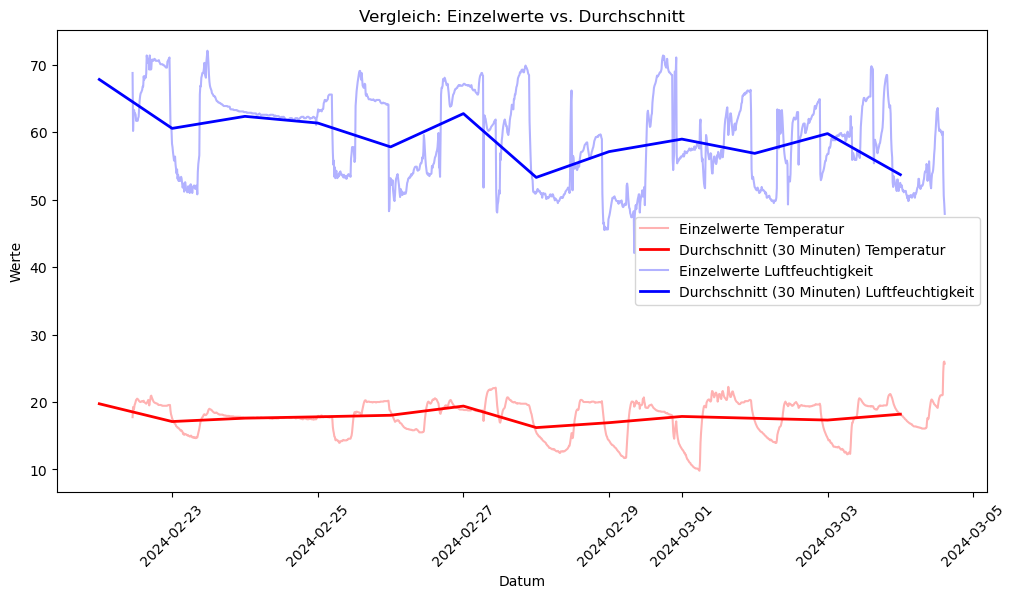

In [14]:
plt.figure(figsize=(12, 6))

# Temperatur: Einzelwerte und Durchschnitt
plt.plot(df.index, df["temperature(C)"], label="Einzelwerte Temperatur", color="red", alpha=0.3)
plt.plot(df_daily.index, df_daily["temperature(C)"], label="Durchschnitt (30 Minuten) Temperatur", color="red", linewidth=2)

# Luftfeuchtigkeit: Einzelwerte und gleitender Durchschnitt
plt.plot(df.index, df["humidity"], label="Einzelwerte Luftfeuchtigkeit", color="blue", alpha=0.3)
plt.plot(df_daily.index, df_daily["humidity"], label="Durchschnitt (30 Minuten) Luftfeuchtigkeit", color="blue", linewidth=2)

# Achsenbeschriftung und Titel
plt.xlabel("Datum")
plt.ylabel("Werte")
plt.title("Vergleich: Einzelwerte vs. Durchschnitt")

# Legende
plt.legend()
plt.xticks(rotation=45)

# Plot anzeigen
plt.show()

### Rolling (Gleitender Durchschnitt)
Gleitende Durchschnitte (engl. *rolling averages*) eignen sich, um kurzzeitige Schwankungen zu glätten und Trends leichter erkennen zu können:


In [16]:
# Gleitender Durchschnitt basierend auf einem Zeitfenster von 1 Stunde
df["temperature_1H"] = df["temperature(C)"].rolling("1h").mean()
df["humidity_1H"] = df["humidity"].rolling("1h").mean()

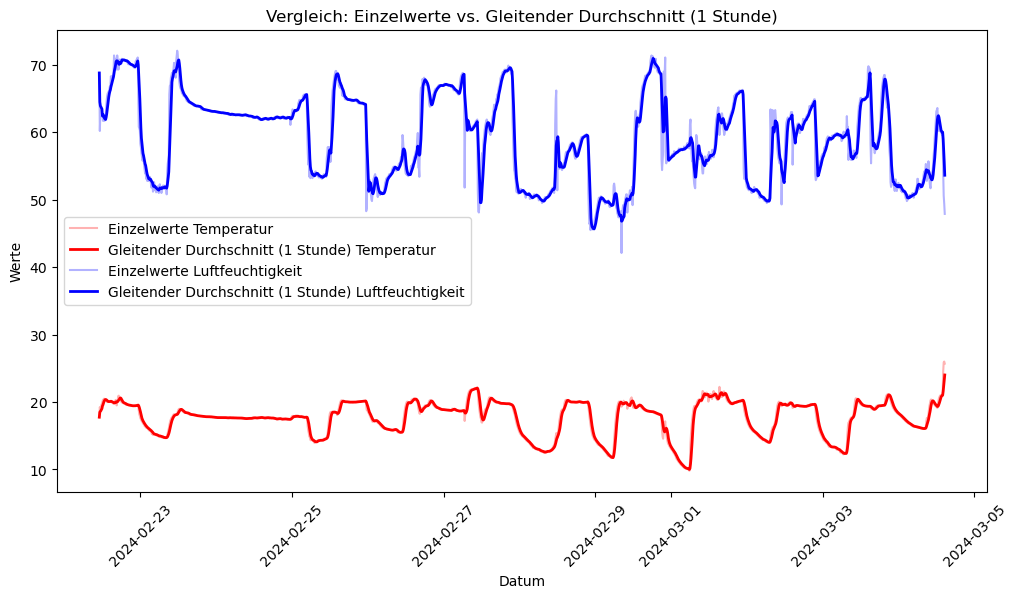

In [17]:
plt.figure(figsize=(12, 6))

# Temperatur: Einzelwerte und gleitender Durchschnitt
plt.plot(df.index, df["temperature(C)"], label="Einzelwerte Temperatur", color="red", alpha=0.3)
plt.plot(df.index, df["temperature_1H"], label="Gleitender Durchschnitt (1 Stunde) Temperatur", color="red", linewidth=2)

# Luftfeuchtigkeit: Einzelwerte und gleitender Durchschnitt
plt.plot(df.index, df["humidity"], label="Einzelwerte Luftfeuchtigkeit", color="blue", alpha=0.3)
plt.plot(df.index, df["humidity_1H"], label="Gleitender Durchschnitt (1 Stunde) Luftfeuchtigkeit", color="blue", linewidth=2)

# Achsenbeschriftung und Titel
plt.xlabel("Datum")
plt.ylabel("Werte")
plt.title("Vergleich: Einzelwerte vs. Gleitender Durchschnitt (1 Stunde)")

# Legende
plt.legend()
plt.xticks(rotation=45)

# Plot anzeigen
plt.show()

Der **Unterschied zwischen `resample()` und `rolling()`** liegt in ihrer Funktionalität und Anwendung auf Zeitreihendaten.

---

### **1. `resample()`: Zeitbasierte Aggregation**
✅ **Zweck:** Gruppiert Daten in größere Zeitintervalle und berechnet Aggregationen (z. B. Mittelwert, Summe, Maximum etc.).  
✅ **Ersetzt vorhandene Zeitstempel durch neue aggregierte Werte.**  

```python
df_minute = df.resample("min").mean()  # Mittelwert für jede Minute
df_daily = df.resample("D").sum()      # Summe pro Tag
```

🔹 **Wichtig:** `resample()` erstellt **neue Zeitstempel** basierend auf den Aggregationsintervallen.  
🔹 **Anwendungsfall:** Wenn du Daten von 10-Sekunden-Intervallen auf Minuten-, Stunden- oder Tageswerte umwandeln möchtest.

---

### **2. `rolling()`: Gleitende Fensterberechnung**
✅ **Zweck:** Berechnet statistische Werte über ein verschiebbares (gleitendes) Zeitfenster.  
✅ **Behält die ursprünglichen Zeitstempel bei.**  

```python
df["temperature_rolling"] = df["temperature(C)"].rolling("1H").mean()  # Gleitender 1-Stunden-Mittelwert
```

🔹 **Wichtig:** `rolling()` verändert **nicht die Zeitstempel**, sondern berechnet den Mittelwert basierend auf dem aktuellen und den vorherigen Werten im Fenster.  
🔹 **Anwendungsfall:** Wenn du Schwankungen in den Daten glätten möchtest, ohne sie zu reduzieren.

---

### **🔍 Vergleich anhand eines Beispiels**
**Angenommen, wir haben folgende Messwerte alle 10 Sekunden:**
| **Zeit**       | **Temperatur (°C)** |
|--------------|------------------|
| 10:00:10    | 20.5             |
| 10:00:20    | 21.0             |
| 10:00:30    | 20.8             |
| 10:00:40    | 21.2             |
| 10:00:50    | 21.1             |
| 10:01:00    | 21.3             |

#### **📌 `resample()` – Aggregation auf Minutenebene**
```python
df_minute = df.resample("min").mean()
```
➡ **Ergebnis:**
| **Zeit** | **Temperatur (°C)** |
|--------------|------------------|
| 10:00:00    | 20.92 (Mittelwert aus 10:00:10 - 10:00:50) |
| 10:01:00    | 21.3 |

📌 **Neuer Zeitindex:** `10:00:00, 10:01:00` (Die Original-Zeitpunkte werden ersetzt.)

---

#### **📌 `rolling()` – Gleitender Durchschnitt**
```python
df["temperature_rolling"] = df["temperature(C)"].rolling("30s").mean()
```
➡ **Ergebnis (gleitender 30s-Durchschnitt für jede Zeile):**
| **Zeit**       | **Temperatur (°C)** | **Gleitender 30s-Mittelwert** |
|--------------|------------------|------------------|
| 10:00:10    | 20.5             | NaN (noch nicht genug Werte) |
| 10:00:20    | 21.0             | NaN (noch nicht genug Werte) |
| 10:00:30    | 20.8             | 20.77 (Mittelwert von 10:00:10 - 10:00:30) |
| 10:00:40    | 21.2             | 21.0 (Mittelwert von 10:00:20 - 10:00:40) |
| 10:00:50    | 21.1             | 21.03 (Mittelwert von 10:00:30 - 10:00:50) |

📌 **Originale Zeitstempel bleiben erhalten, nur die neuen Werte werden ergänzt.**

---

### **🚀 Fazit: Wann `resample()` und wann `rolling()` nutzen?**
| **Methode** | **Wann verwenden?** |
|------------|----------------|
| `resample()` | Wenn du die Daten **neu strukturieren** und in größere Zeiträume aggregieren willst (z. B. stündlich, täglich). **Erzeugt neue Zeitstempel.** |
| `rolling()` | Wenn du eine **gleitende Berechnung** (z. B. Mittelwert) machen willst, **ohne die Zeitstempel zu ändern.** Nützlich zur Glättung von Daten. |

✨ **Merke:**  
- **Resampling reduziert die Anzahl der Datenpunkte.**  
- **Rolling berechnet Werte auf Basis eines Fensters, ohne Daten zu entfernen.**  


---
## Daten visualisieren

Für Zeitreihen bietet es sich an, die x-Achse als Zeitachse zu verwenden und die y-Achse für den Wert. Mit Matplotlib oder Seaborn können wir schnell erste Einblicke gewinnen.

###  Überblicksplot

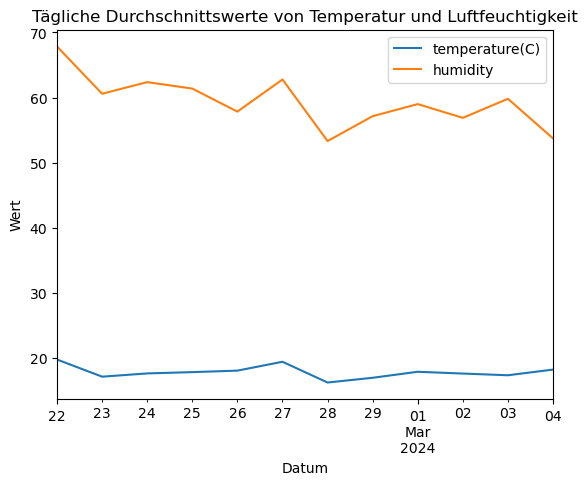

In [20]:
# Einfacher Plot mit Matplotlib
df_daily[['temperature(C)', 'humidity']].plot()
plt.title('Tägliche Durchschnittswerte von Temperatur und Luftfeuchtigkeit')
plt.xlabel('Datum')
plt.ylabel('Wert')
plt.show()

### Differenzen berechnen (zur Erkennung von Trends)
Um Trends zu entfernen oder stationäre Zeitreihen für Prognosen zu erzeugen, wendet man häufig Differenzen an:


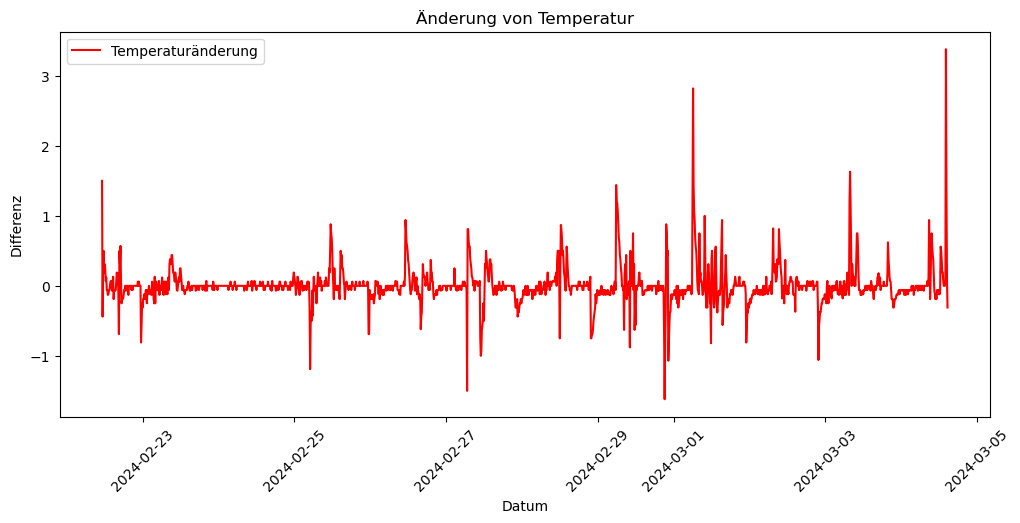

In [22]:
# Differenz zum nachbarswert
df["temperature_diff"] = df["temperature(C)"].diff()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["temperature_diff"], label="Temperaturänderung", color="red")
plt.xlabel("Datum")
plt.ylabel("Differenz")
plt.title("Änderung von Temperatur")
plt.legend()
plt.xticks(rotation=45)
plt.show()


### Mehrere Plots
Man kann natürlich auch separat plotten oder Seaborn-Funktionen verwenden, wobei Seaborn in der Regel etwas „schönere“ Standardformatierungen hat. Ein Beispiel für separate Plots in Matplotlib:


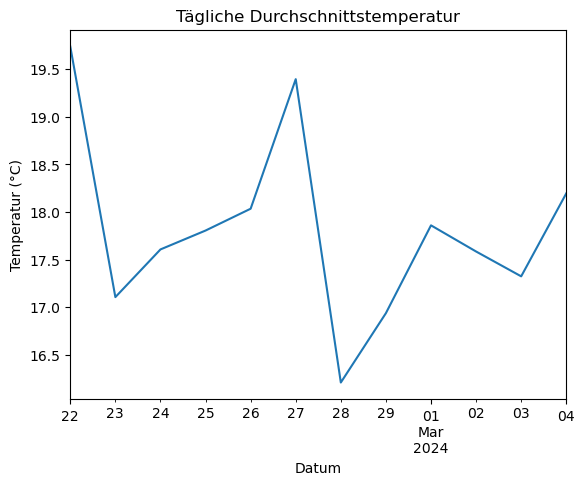

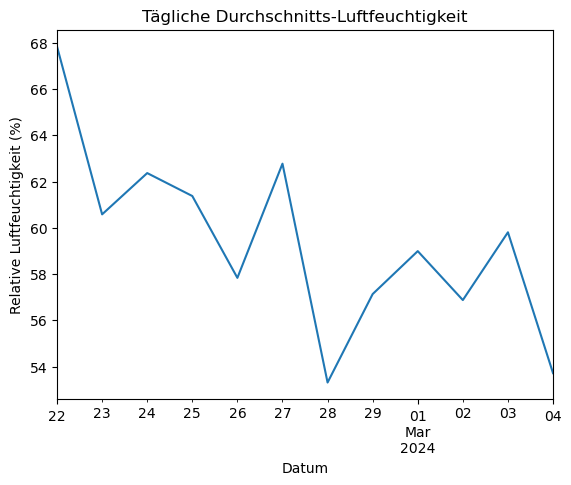

In [24]:
# Temperatur plotten
df_daily['temperature(C)'].plot()
plt.title('Tägliche Durchschnittstemperatur')
plt.xlabel('Datum')
plt.ylabel('Temperatur (°C)')
plt.show()

# Luftfeuchtigkeit plotten
df_daily['humidity'].plot()
plt.title('Tägliche Durchschnitts-Luftfeuchtigkeit')
plt.xlabel('Datum')
plt.ylabel('Relative Luftfeuchtigkeit (%)')
plt.show()

### Shifting (Verschieben)
Mit dem **Shift** kann man Daten nach vorn oder hinten verschieben. Das ist nützlich für das Erstellen von Merkmalen (Features) in Vorhersagemodellen oder Korrelationen:

In [26]:
# Verschiebe die Temperaturwerte um 1 Tag
df_daily['Temperature_shifted'] = df_daily['temperature(C)'].shift(1)

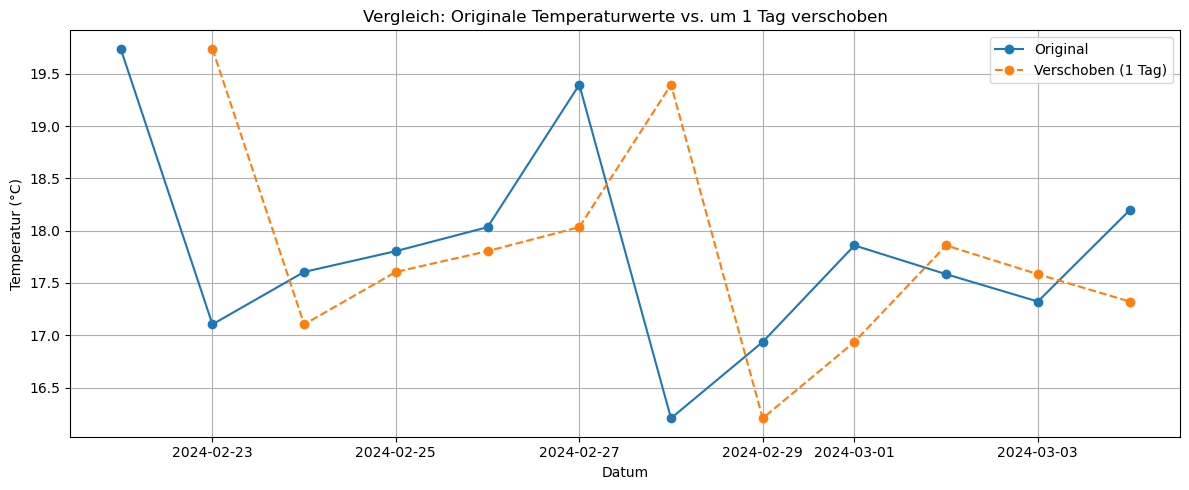

In [27]:
# Plot: Original vs. verschoben
plt.figure(figsize=(12, 5))
plt.plot(df_daily.index, df_daily["temperature(C)"], marker='o', label="Original")
plt.plot(df_daily.index, df_daily["Temperature_shifted"], marker='o', linestyle='--', label="Verschoben (1 Tag)")
plt.title("Vergleich: Originale Temperaturwerte vs. um 1 Tag verschoben")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---

## 📌 **Saisonale Zerlegung (Decomposition)**
**👉 Was ist das?**  
Eine Zeitreihe besteht oft aus **drei Hauptkomponenten**:
1. **Trend**: Langfristige Entwicklung (steigt oder fällt die Temperatur im Laufe der Zeit?).
2. **Saisonalität**: Wiederkehrende Muster (z. B. täglich höhere Temperaturen am Mittag, niedrigere in der Nacht).
3. **Residuen (Rauschen)**: Zufällige Schwankungen, die nicht vorhersehbar sind.

**👉 Warum ist das wichtig?**  
- Zeigt uns, **ob es regelmäßige Muster gibt**.
- Trennt **den echten Trend von kurzfristigen Schwankungen**.
- Hilft, bessere Prognosen zu erstellen.

**👉 Wie funktioniert das?**  
Mit der Funktion `seasonal_decompose()` aus `statsmodels` können wir eine Zeitreihe in **diese drei Bestandteile** zerlegen.


Wir laden an dieser Stelle eine syntetisch erzeugte CSV Datei für Lernzwecke.

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Datei einlesen
file_path = "synthetic_time_series.csv"
df = pd.read_csv(file_path)
# Datumsformat umwandeln und als Index setzen
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
display(df)

,Temperature,Humidity
Date,,
2022-01-01,-9.307977,84.811259
2022-01-02,-9.903083,80.955140
2022-01-03,-9.074362,86.369837
2022-01-04,-8.153370,84.769662
2022-01-05,-9.862030,86.927035
...,...,...
2024-12-27,-4.972260,81.952825
2024-12-28,-4.179211,81.231117
2024-12-29,-4.823766,83.588989


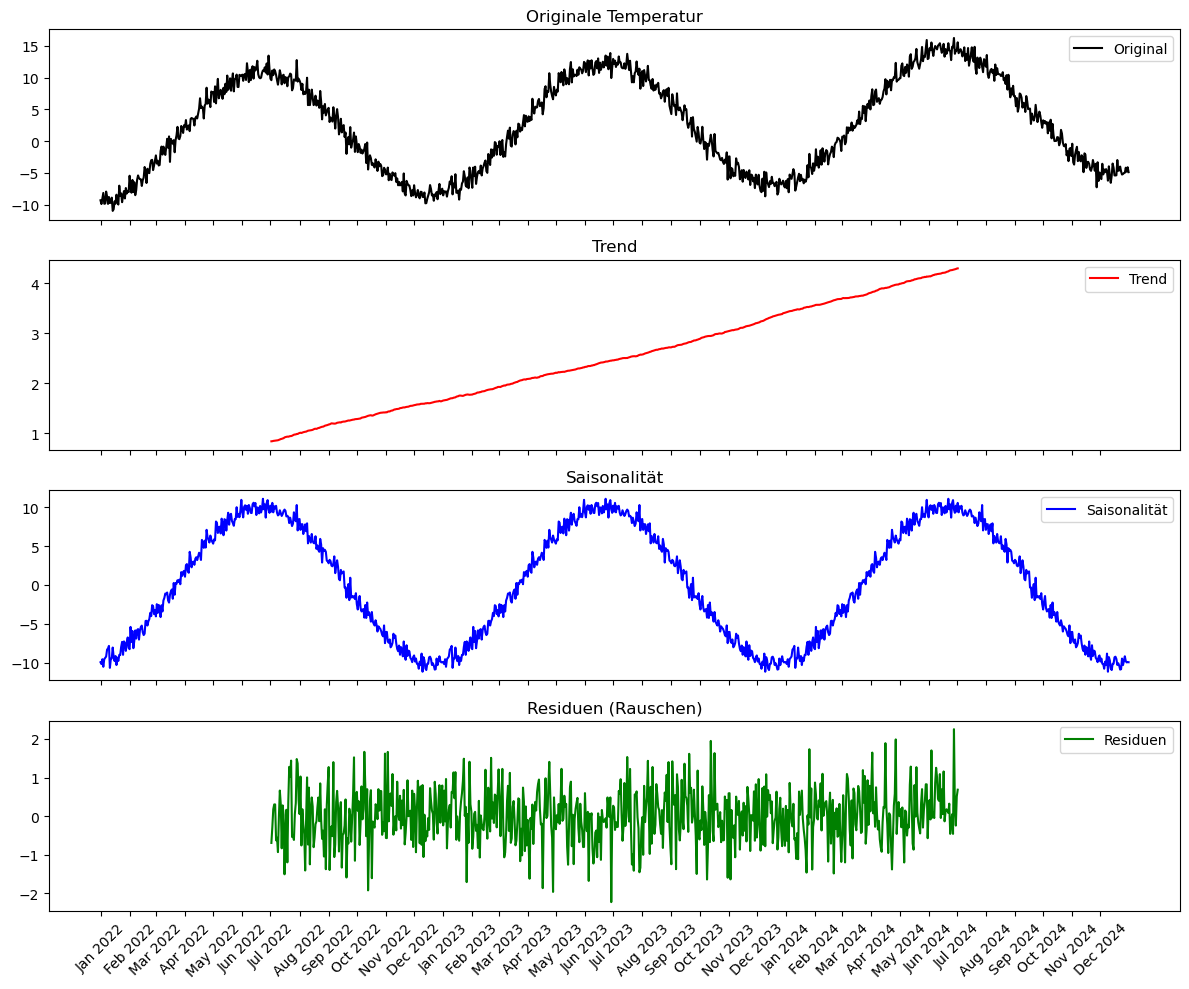

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

# Saisonale Zerlegung der Temperatur mit einer Periode von 365 Tagen
result = seasonal_decompose(df["Temperature"], model="additive", period=365)

# Plot erstellen
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Originaldaten
axes[0].plot(df.index, df["Temperature"], label="Original", color="black")
axes[0].set_title("Originale Temperatur")
axes[0].legend()

# Trend
axes[1].plot(df.index, result.trend, label="Trend", color="red")
axes[1].set_title("Trend")
axes[1].legend()

# Saisonalität
axes[2].plot(df.index, result.seasonal, label="Saisonalität", color="blue")
axes[2].set_title("Saisonalität")
axes[2].legend()

# Residuen (Rauschen)
axes[3].plot(df.index, result.resid, label="Residuen", color="green")
axes[3].set_title("Residuen (Rauschen)")
axes[3].legend()

# X-Achse anpassen: Monatliche Labels setzen
xticks = pd.date_range(start=df.index.min(), end=df.index.max(), freq="MS")
axes[3].set_xticks(xticks)
axes[3].set_xticklabels(xticks.strftime("%b %Y"), rotation=45)

# Layout anpassen und anzeigen
plt.tight_layout()
plt.show()


**👉 Additiv oder Multiplikativ?**
- **Additiv**: Die saisonalen Schwankungen bleiben **konstant** (z. B. gleiche Temperaturdifferenzen zwischen Tag und Nacht).
- **Multiplikativ**: Die saisonalen Schwankungen **verändern sich prozentual** (z. B. Sommer = größere Schwankungen als Winter).

### **Multiplikatives Modell (`model="multiplicative"`) – Kurz erklärt**  

Ein **multiplikatives Modell** bedeutet, dass die saisonalen Schwankungen **prozentual zur Grundgröße** variieren.  

**📌 Beispiel:**
- Eine Stadt mit **milden Temperaturen (10–20°C)** hat **kleine saisonale Schwankungen** (+/-2°C).  
- Eine Stadt mit **extremen Temperaturen (0–40°C)** hat **größere saisonale Schwankungen** (+/-10°C).  

**🛠 Wann sinnvoll?**
✅ Wenn saisonale Schwankungen **proportional** zur Höhe des Trends sind.  
✅ Typisch für **Wirtschaftsdaten (Umsatz, Nachfrage, Inflation)** oder **relative Messwerte (Wachstumsraten, Bevölkerungszahlen)**.  

**⚠ Warum nicht für Temperaturen?**
🚫 Temperaturen haben meist **absolute Schwankungen**, unabhängig vom Niveau (Sommer/Winter bleibt konstant unterschiedlich).  
🚫 Funktioniert **nicht mit negativen oder nullwertigen Daten**, da Multiplikation mit 0 oder negativen Werten nicht sinnvoll ist.  

**🔹 Alternative:**  
**Für Temperaturen ist das additive Modell (`model="additive"`) besser geeignet!** 😊

---

## 📌 **Autokorrelation (ACF)**
**👉 Was ist das?**  
Autokorrelation zeigt uns, **wie stark ein Wert von vorherigen Werten beeinflusst wird**.  
Beispiel:
- Ist die Temperatur **heute ähnlich wie gestern**?
- Gibt es eine **wöchentliche oder tägliche Wiederholung** in den Daten?

**👉 Warum ist das wichtig?**  
- Hilft uns zu verstehen, ob **alte Werte die Zukunft beeinflussen**.
- Zeigt **wiederkehrende Muster** (z. B. **alle 7 Tage oder alle 24 Stunden** eine Ähnlichkeit).
- Wichtig für **Prognosen**: Je stärker die Autokorrelation, desto **besser lassen sich Werte vorhersagen**.

**👉 Wie funktioniert das?**  
Mit `autocorrelation_plot()` können wir eine **visuelle Darstellung** der Autokorrelation erzeugen.

### **🔧 Beispiel (Code)**

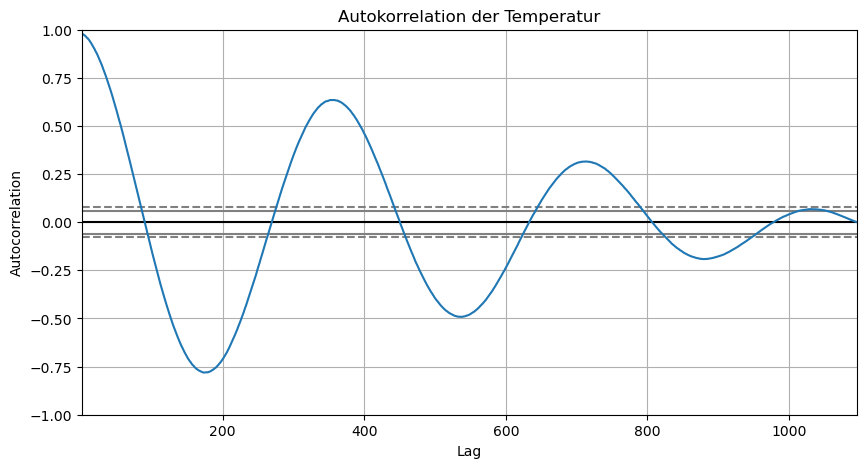

In [34]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
autocorrelation_plot(df["Temperature"])
plt.title("Autokorrelation der Temperatur")
plt.show()

**👉 Wie liest man das Diagramm?**
Das **Autokorrelationsdiagramm (ACF-Plot)** zeigt, wie stark die Temperaturwerte mit ihren eigenen vergangenen Werten korrelieren.  

#### **1️⃣ Hohe Werte zu bestimmten Lags → Wiederholungen**
- Die Wellenform weist auf **starke saisonale Muster** hin.
- Es gibt **hohe Peaks in regelmäßigen Abständen**, was bedeutet, dass sich die Temperaturwerte **nach einer bestimmten Zeit wiederholen**.

#### **2️⃣ Was bedeuten die Lags?**
- **Lag 0 → Perfekte Korrelation (1.0)**, weil ein Wert immer mit sich selbst korreliert.
- **Lag ~365 → Hoher Peak**  
  → Das bedeutet, dass die Temperatur **ungefähr nach einem Jahr ähnlich ist** (typischer Jahreszyklus).
- **Lag ~180 → Negativer Wert**  
  → Nach etwa einem halben Jahr (Winter/Sommer) ist die Temperatur entgegengesetzt (Sommer heiß, Winter kalt).

#### **3️⃣ Interpretation der Form**
- **Wellenförmiges Muster** → Deutlicher **Jahreszyklus** (Juli heiß, Januar kalt).
- **Schneller Abfall bei kleinen Lags** → Kurzfristige Temperaturwerte hängen **nur begrenzt voneinander ab**.
- **Wiederkehrende Peaks bei ca. 365 Tagen** → Saisonale Periodizität (Wiederholung jedes Jahr).

#### **📌 Fazit**
✅ **Temperatur folgt einem starken saisonalen Muster** (Sommer/Winter-Unterschiede).  
✅ **Autokorrelation ist hoch bei 365 Tagen** → Temperaturen ähneln sich nach einem Jahr.  
✅ **Nach 180 Tagen ist sie negativ** → Typische Gegenbewegung (Sommer vs. Winter).  

---

## 📌 **Einfache Prognosemethoden**
### **a) Naiver Forecast**
**👉 Was ist das?**  
Eine **extrem einfache** Vorhersagemethode:  
➡ **Nimm den letzten bekannten Wert als Prognose für die Zukunft.**  

**📌 Beispiel:**
- Heute ist es **20°C** → Sage für morgen einfach **20°C** vorher.

**👉 Warum ist das wichtig?**  
- Zeigt, **wie gut einfache Prognosen** schon funktionieren können.
- Ist eine **Basislinie** zum Vergleich mit besseren Modellen.

**👉 Wie funktioniert das?**  
Wir nehmen den **letzten bekannten Wert** und wiederholen ihn für alle zukünftigen Zeitpunkte.



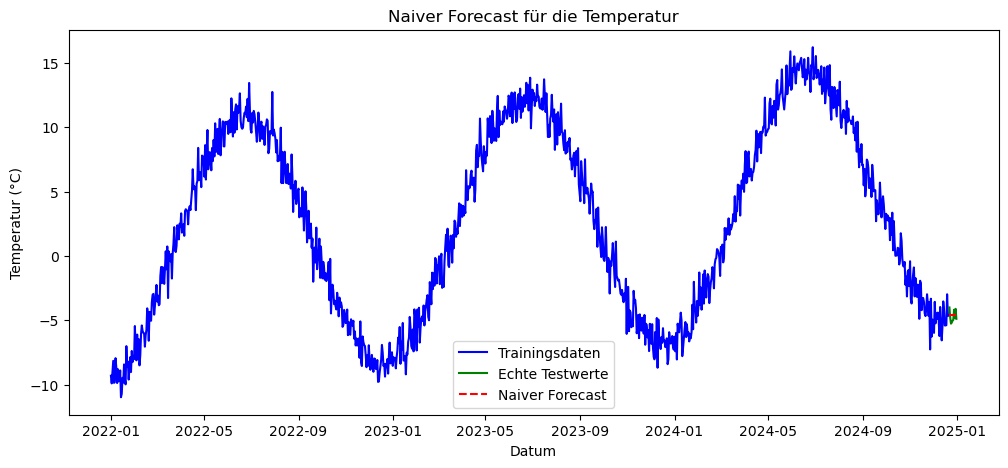

In [37]:
# Trainings- und Testdaten aufteilen
train = df.iloc[:-10]  # Letzten 10 Tage als Testdaten ausschließen
test = df.iloc[-10:]  # Die letzten 10 Tage als Testdaten

# Naiver Forecast: Wiederhole den letzten bekannten Wert für die gesamte Testperiode
naive_forecast = np.repeat(train["Temperature"].iloc[-1], len(test))

# Plotten der echten Werte und der Prognose
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Temperature"], label="Trainingsdaten", color="blue")
plt.plot(test.index, test["Temperature"], label="Echte Testwerte", color="green")
plt.plot(test.index, naive_forecast, label="Naiver Forecast", linestyle="dashed", color="red")
plt.legend()
plt.title("Naiver Forecast für die Temperatur")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.show()



- **Der Naive Forecast ist kein intelligentes Modell**, aber eine **nützliche Benchmark**.
- **Er hilft zu überprüfen**, ob komplexe Modelle wirklich besser sind.
- **Für sehr kurzfristige Vorhersagen** kann er überraschend gut funktionieren.



### **🔹 Erweiterung: Seasonal Naive Forecast**
Statt den **letzten Wert** zu nehmen, können wir den Wert **vom letzten Jahr** als Vorhersage nutzen:

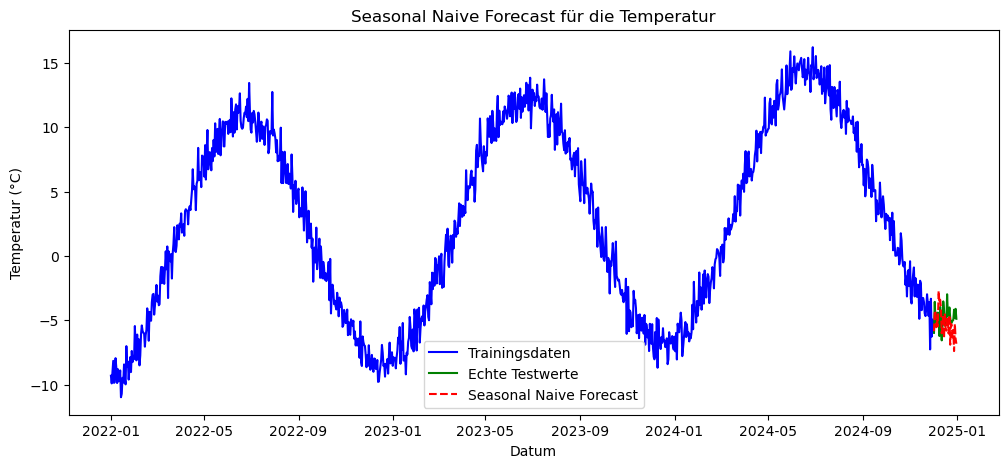

In [40]:

# Trainings- und Testdaten aufteilen
train = df.iloc[:-30]  # Letzten 30 Tage als Testdaten ausschließen
test = df.iloc[-30:]  # Die letzten 30 Tage als Testdaten

# Seasonal Naive Forecast: Nutze den Wert vom gleichen Tag des letzten Jahres mittels shift(365)
seasonal_naive_forecast = train["Temperature"].shift(365).iloc[-30:].values

# Plotten der echten Werte und der Prognose
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Temperature"], label="Trainingsdaten", color="blue")
plt.plot(test.index, test["Temperature"], label="Echte Testwerte", color="green")
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive Forecast", linestyle="dashed", color="red")
plt.legend()
plt.title("Seasonal Naive Forecast für die Temperatur")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.show()


---

### **b) Holt-Winters (Exponentielle Glättung)**
**👉 Was ist das?**  
Ein besseres Modell als der Naive Forecast, weil es:
1. Den **Trend** berücksichtigt (steigt oder fällt die Temperatur über Zeit?).
2. **Saisonalität** einbezieht (Wiederholungen wie Tageszyklen).

**👉 Warum ist das wichtig?**  
- Holt-Winters **passt sich an Veränderungen an**.
- Funktioniert für **Zeitreihen mit Trend und saisonalen Mustern**.

C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


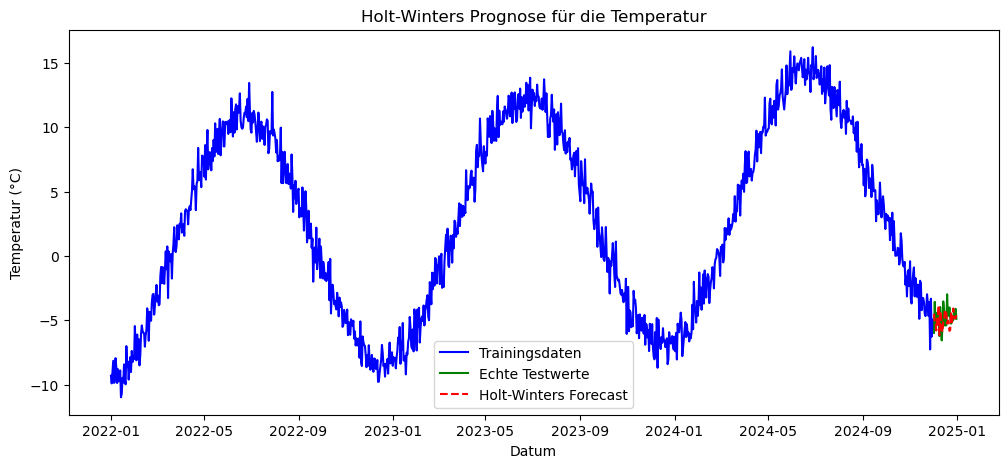

In [42]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Holt-Winters Modell mit Trend und Saison
model = ExponentialSmoothing(train["Temperature"], trend="add", seasonal="add", seasonal_periods=365)
fitted_model = model.fit()
forecast = fitted_model.forecast(steps=30)

# Plotten der echten Werte und der Prognose
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Temperature"], label="Trainingsdaten", color="blue")
plt.plot(test.index, test["Temperature"], label="Echte Testwerte", color="green")
plt.plot(test.index, forecast, label="Holt-Winters Forecast", linestyle="dashed", color="red")
plt.legend()
plt.title("Holt-Winters Prognose für die Temperatur")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.show()


➡ **Besser als der Naive Forecast**, weil er **Trend & Saison berücksichtigt**.

---

## 📌 **Prognosequalität messen**
**👉 Warum ist das wichtig?**  
Wir wollen wissen, **wie gut unsere Prognose wirklich ist**!  
Das machen wir mit **Fehlermetriken** wie **MSE, RMSE und MAE**.

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prognosequalität messen
mse = mean_squared_error(test["Temperature"], forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test["Temperature"], forecast)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")


Mean Squared Error (MSE): 0.98
Root Mean Squared Error (RMSE): 0.99
Mean Absolute Error (MAE): 0.81


➡ **Je kleiner der Fehler, desto besser die Vorhersage!** 🚀
### **📌 Interpretation der Prognosefehlerwerte**  

Diese **Fehlermetriken** helfen uns zu verstehen, **wie gut unsere Prognose im Vergleich zu den echten Werten abschneidet**.

---

### **📌 Fazit:**
- **MSE (0.98):** Gut zur mathematischen Optimierung, aber schwer verständlich.  
- **RMSE (0.99):** Durchschnittlicher Fehler in °C, betont größere Fehler stärker.  
- **MAE (0.81):** Durchschnittlicher Fehler in °C, einfacher zu interpretieren.  

**➡ Die Prognose weicht im Schnitt um etwa 0.8–1°C von den echten Werten ab.**  
Das ist eine **solide Vorhersage**, abhängig von der Anwendung. Falls du eine genauere Prognose möchtest, kannst du alternative Modelle wie **ARIMA, LSTMs oder Prophet** testen! 🚀😊

---

## **🚀 Fazit**
| **Thema** | **Ziel** |
|-----------|---------|
| **Saisonale Zerlegung** | Trend, Saison und Rauschen sichtbar machen |
| **Autokorrelation (ACF)** | Wiederkehrende Muster entdecken |
| **Naiver Forecast** | Einfache Prognose mit letztem Wert |
| **Holt-Winters Modell** | Berücksichtigt Trend und Saison |
| **Fehlermetriken (MSE, RMSE, MAE)** | Prognosequalität bewerten |

**Ergebnis:** Du kannst **Trends & Saisonalitäten erkennen, Autokorrelation analysieren und erste Vorhersagen erstellen!** 🎯🚀


---

**Ausblick**:  
- Für tiefergehende statistische Modellierung sind Bibliotheken wie [**statsmodels**](https://www.statsmodels.org/) (ARIMA, SARIMA, etc.) oder [**pmdarima**](https://github.com/alkaline-ml/pmdarima) interessant.  
- Für neuronale Netze und Machine-Learning-Modelle (z.B. RNNs, LSTMs, Transformers) kann man mit [**TensorFlow**](https://www.tensorflow.org/) oder [**PyTorch**](https://pytorch.org/) arbeiten.

Mit diesem Wissen kannst du bereits viele Fragestellungen in der Zeitreihenanalyse eigenständig angehen und erste Prognosen oder Analysen erstellen. Viel Erfolg dabei!